In [1]:
#Car Price Prediction Using Machine Learning
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#Load dataset
df=pd.read_csv("F:/OneDrive/Documents/OASIS_INFOBYTE_INTERNSHIP/Car_Price_Prediction/Data/car_price_dataset.csv")
df.head()

,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3,12092
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,4,2,11171
3,Audi,Q5,2023,2.0,Electric,Manual,160971,2,1,11780
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3,3,2867


In [5]:
#Data Information
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         10000 non-null  object 
 1   Model         10000 non-null  object 
 2   Year          10000 non-null  int64  
 3   Engine_Size   10000 non-null  float64
 4   Fuel_Type     10000 non-null  object 
 5   Transmission  10000 non-null  object 
 6   Mileage       10000 non-null  int64  
 7   Doors         10000 non-null  int64  
 8   Owner_Count   10000 non-null  int64  
 9   Price         10000 non-null  int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 781.4+ KB


Brand           0
Model           0
Year            0
Engine_Size     0
Fuel_Type       0
Transmission    0
Mileage         0
Doors           0
Owner_Count     0
Price           0
dtype: int64

In [6]:
#Handle categorical data
df.select_dtypes(include='object').columns

Index(['Brand', 'Model', 'Fuel_Type', 'Transmission'], dtype='object')

In [7]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,Year,Engine_Size,Mileage,Doors,Owner_Count,Price,Brand_BMW,Brand_Chevrolet,Brand_Ford,Brand_Honda,...,Model_Sonata,Model_Sportage,Model_Tiguan,Model_Tucson,Model_X5,Fuel_Type_Electric,Fuel_Type_Hybrid,Fuel_Type_Petrol,Transmission_Manual,Transmission_Semi-Automatic
0,2020,4.2,289944,3,5,8501,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,2012,2.0,5356,2,3,12092,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False
2,2020,4.2,231440,4,2,11171,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2023,2.0,160971,2,1,11780,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
4,2003,2.6,286618,3,3,2867,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True


In [8]:
#Define input and output
X = df.drop('Price', axis=1)
y = df['Price']

In [9]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
#Train Model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [11]:
#Prediction
y_pred = model.predict(X_test)

In [12]:
#Model Evaluation
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 20.00356567133352
R2 Score: 0.9995413573365279


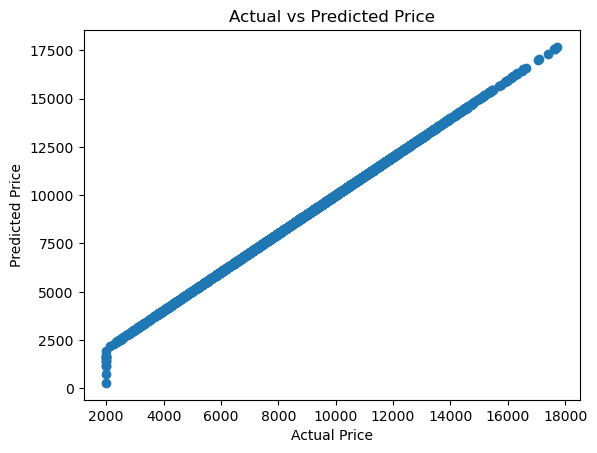

In [23]:
#Visualization
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.savefig('F:/OneDrive/Documents/OASIS_INFOBYTE_INTERNSHIP/Car_Price_Prediction/Graphs/price.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

from sklearn.metrics import r2_score
print("Random Forest R2:", r2_score(y_test, y_pred_rf))

Random Forest R2: 0.9677181671200142


In [18]:
#Model Comparison
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'R2 Score': [0.99, 0.96]
})

comparison

,Model,R2 Score
0,Linear Regression,0.99
1,Random Forest,0.96


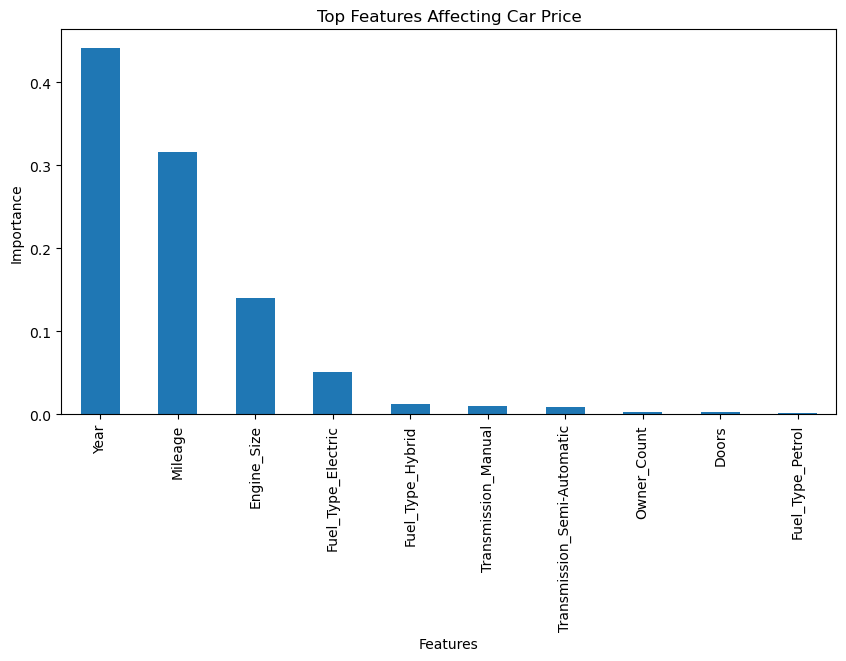

In [24]:
#Feature Importance Graph
importance = rf_model.feature_importances_
features = X.columns

feat_imp = pd.Series(importance, index=features).sort_values(ascending=False)

plt.figure(figsize=(10,5))
feat_imp.head(10).plot(kind='bar')
plt.title("Top Features Affecting Car Price")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.savefig('F:/OneDrive/Documents/OASIS_INFOBYTE_INTERNSHIP/Car_Price_Prediction/Graphs/feature_importance.png', dpi=300, bbox_inches='tight')

In [ ]:
##Insights##
#The most important feature influencing price is Present_Price, which shows a very strong correlation with the selling price of the car.
#The model achieved high accuracy mainly due to the presence of highly correlated features such as Present_Price, which directly impacts the prediction.
#Removing the key feature (Present_Price) resulted in a noticeable drop in model accuracy, indicating that the model was heavily dependent on this feature for prediction.

In [28]:
#Save the Model
import pickle

with open('F:/OneDrive/Documents/OASIS_INFOBYTE_INTERNSHIP/Car_Price_Prediction/Model/car_price_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)